# 1.0 Import modules and verify BayesISOLA

This notebook first runs **BayesISOLA natively**, following the package architecture as closely as possible.  
Custom miniSEED/SAC loading, custom response processing, and external velocity-model preparation should be added only after the native workflow is working for this event.

## 1.1 Import modules and locate the BayesISOLA repository

BayesISOLA is cloned as a source repository rather than installed as a normal Python package.  
The repository root is therefore added to `sys.path` **before** importing `BayesISOLA`. The working directory is also set to the repository root because BayesISOLA/Axitra uses relative paths under `green/`.

In [1]:
from IPython.display import display

from pathlib import Path
import pandas as pd

from gf_helpers import (
    build_regular_velocity_grid
)

from bayesisola_helpers import (
    run_auto_cmt,
    get_mseed_stationxml
)

import BayesISOLA

/home/ara299/dev/venv310_org/src/BayesISOLA/BayesISOLA/__init__.py


## 1.2 Set case directories

Keep the first implementation inside BayesISOLA's own `input/` and `output/` structure.  
This avoids mixing the native baseline with the existing MTtime processing tree.

In [2]:
event_id = "2026p530771"

output_path = Path(
    f"{event_id}"
)

output_path.mkdir(parents=True, exist_ok=True)

raw_path = output_path / "raw"
metadata_path = output_path / "metadata"
input_path = output_path / "input"

input_path.mkdir(parents=True, exist_ok=True)

network_file = input_path / "network.stn"
crust_file = input_path / "crustal.dat"

print("Event directory :", output_path)
print("Raw data        :", raw_path)
print("Metadata        :", metadata_path)
print("BayesISOLA input:", input_path)

Event directory : /mnt/c/Users/ara299/NZGMDB/bayesisola/2026p530771
Raw data        : /mnt/c/Users/ara299/NZGMDB/bayesisola/2026p530771/raw
Metadata        : /mnt/c/Users/ara299/NZGMDB/bayesisola/2026p530771/metadata
BayesISOLA input: /mnt/c/Users/ara299/NZGMDB/bayesisola/2026p530771/input


## 1.3 Define velocity model

In [3]:
vm_folder = Path(r'vm')

nz_3dvm = pd.read_csv(vm_folder / "vlnzw2p3dnxyzltln.tbl.txt", skiprows = 2, sep='\s+', names=["Vp", "Vp/Vs", "Vs", "Density", "SF_Vp", "SF_Vp/Vs", "x(km)", "y(km)", "Depth(km_BSL)", "Latitude", "Longitude"])
nz_3dvm_qp = pd.read_csv(vm_folder / "Qpnzw2p3xyzltln.tbl.txt", skiprows = 2, sep='\s+', names=["Qp","SF_Qp","x(km)","y(km)", "Depth(km_BSL)", "Latitude", "Longitude"])
nz_3dvm_qs = pd.read_csv(vm_folder / "Qsnzw2p3xyzltln.tbl.txt", skiprows = 2, sep='\s+', names=["Qs","SF_Qs","x(km)","y(km)", "Depth(km_BSL)", "Latitude", "Longitude"])

nz_3dvm[["Qp","SF_Qp"]] = nz_3dvm_qp[["Qp","SF_Qp"]]
nz_3dvm[["Qs","SF_Qs"]] = nz_3dvm_qs[["Qs","SF_Qs"]]

nz_grid_ll = build_regular_velocity_grid(
    nz_3dvm,
    x_col="Longitude",
    y_col="Latitude",
    depth_col="Depth(km_BSL)",
    vp_col="Vp",
    vs_col="Vs",
    density_col="Density",
    qs_col="Qs",
    qp_col="Qp",
    coordinate_crs="EPSG:4326",
    interpolation_crs="EPSG:2193"
)

# 2.0 Compute CMT

The sequence below follows BayesISOLA's native workflow:

1. initialise the event and source-time function;
2. read the BayesISOLA station file;
3. read the BayesISOLA crustal model;
4. download raw waveforms and responses using BayesISOLA;
5. run BayesISOLA component/transient quality control;
6. construct the space-time centroid grid;
7. let BayesISOLA process the observations and calculate/verify Axitra Green's functions;
8. construct the noise covariance matrix;
9. invert the full moment tensor;
10. generate BayesISOLA's native diagnostics and report.

## 2.1 Specify event details

In [4]:
event_id = "2026p530771"

event_time = "2026-07-16T09:14:54.328610Z"
lon_event = 167.681930541992
lat_event = -45.038818359375
depth_km = 37.5175437927246
mag_event = 5.9

min_radius_km = 0.0
max_radius_km = 600.0

## 2.2 Auto CMT: FDSN mode

Green's functions (m36f18d56699e):   0%|          | 0/5246 [00:00<?, ?pt/s]

Green's functions (m18370559db43):   0%|          | 0/5246 [00:00<?, ?pt/s]

Green's functions (m743cda5cf6cb):   0%|          | 0/5246 [00:00<?, ?pt/s]

Green's functions (m4e17facfa5d3):   0%|          | 0/5246 [00:00<?, ?pt/s]

Green's functions (m190806eaa1dc):   0%|          | 0/5246 [00:00<?, ?pt/s]

...

Green's functions (m13dec9a8bd58):   0%|          | 0/5246 [00:00<?, ?pt/s]

Green's functions (mc71bec3703fb):   0%|          | 0/5246 [00:00<?, ?pt/s]

Green's functions (m28c5dd7c53e9):   0%|          | 0/5246 [00:00<?, ?pt/s]

Moment-tensor inversion:   0%|          | 0/5240 [00:00<?, ?pt/s]

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


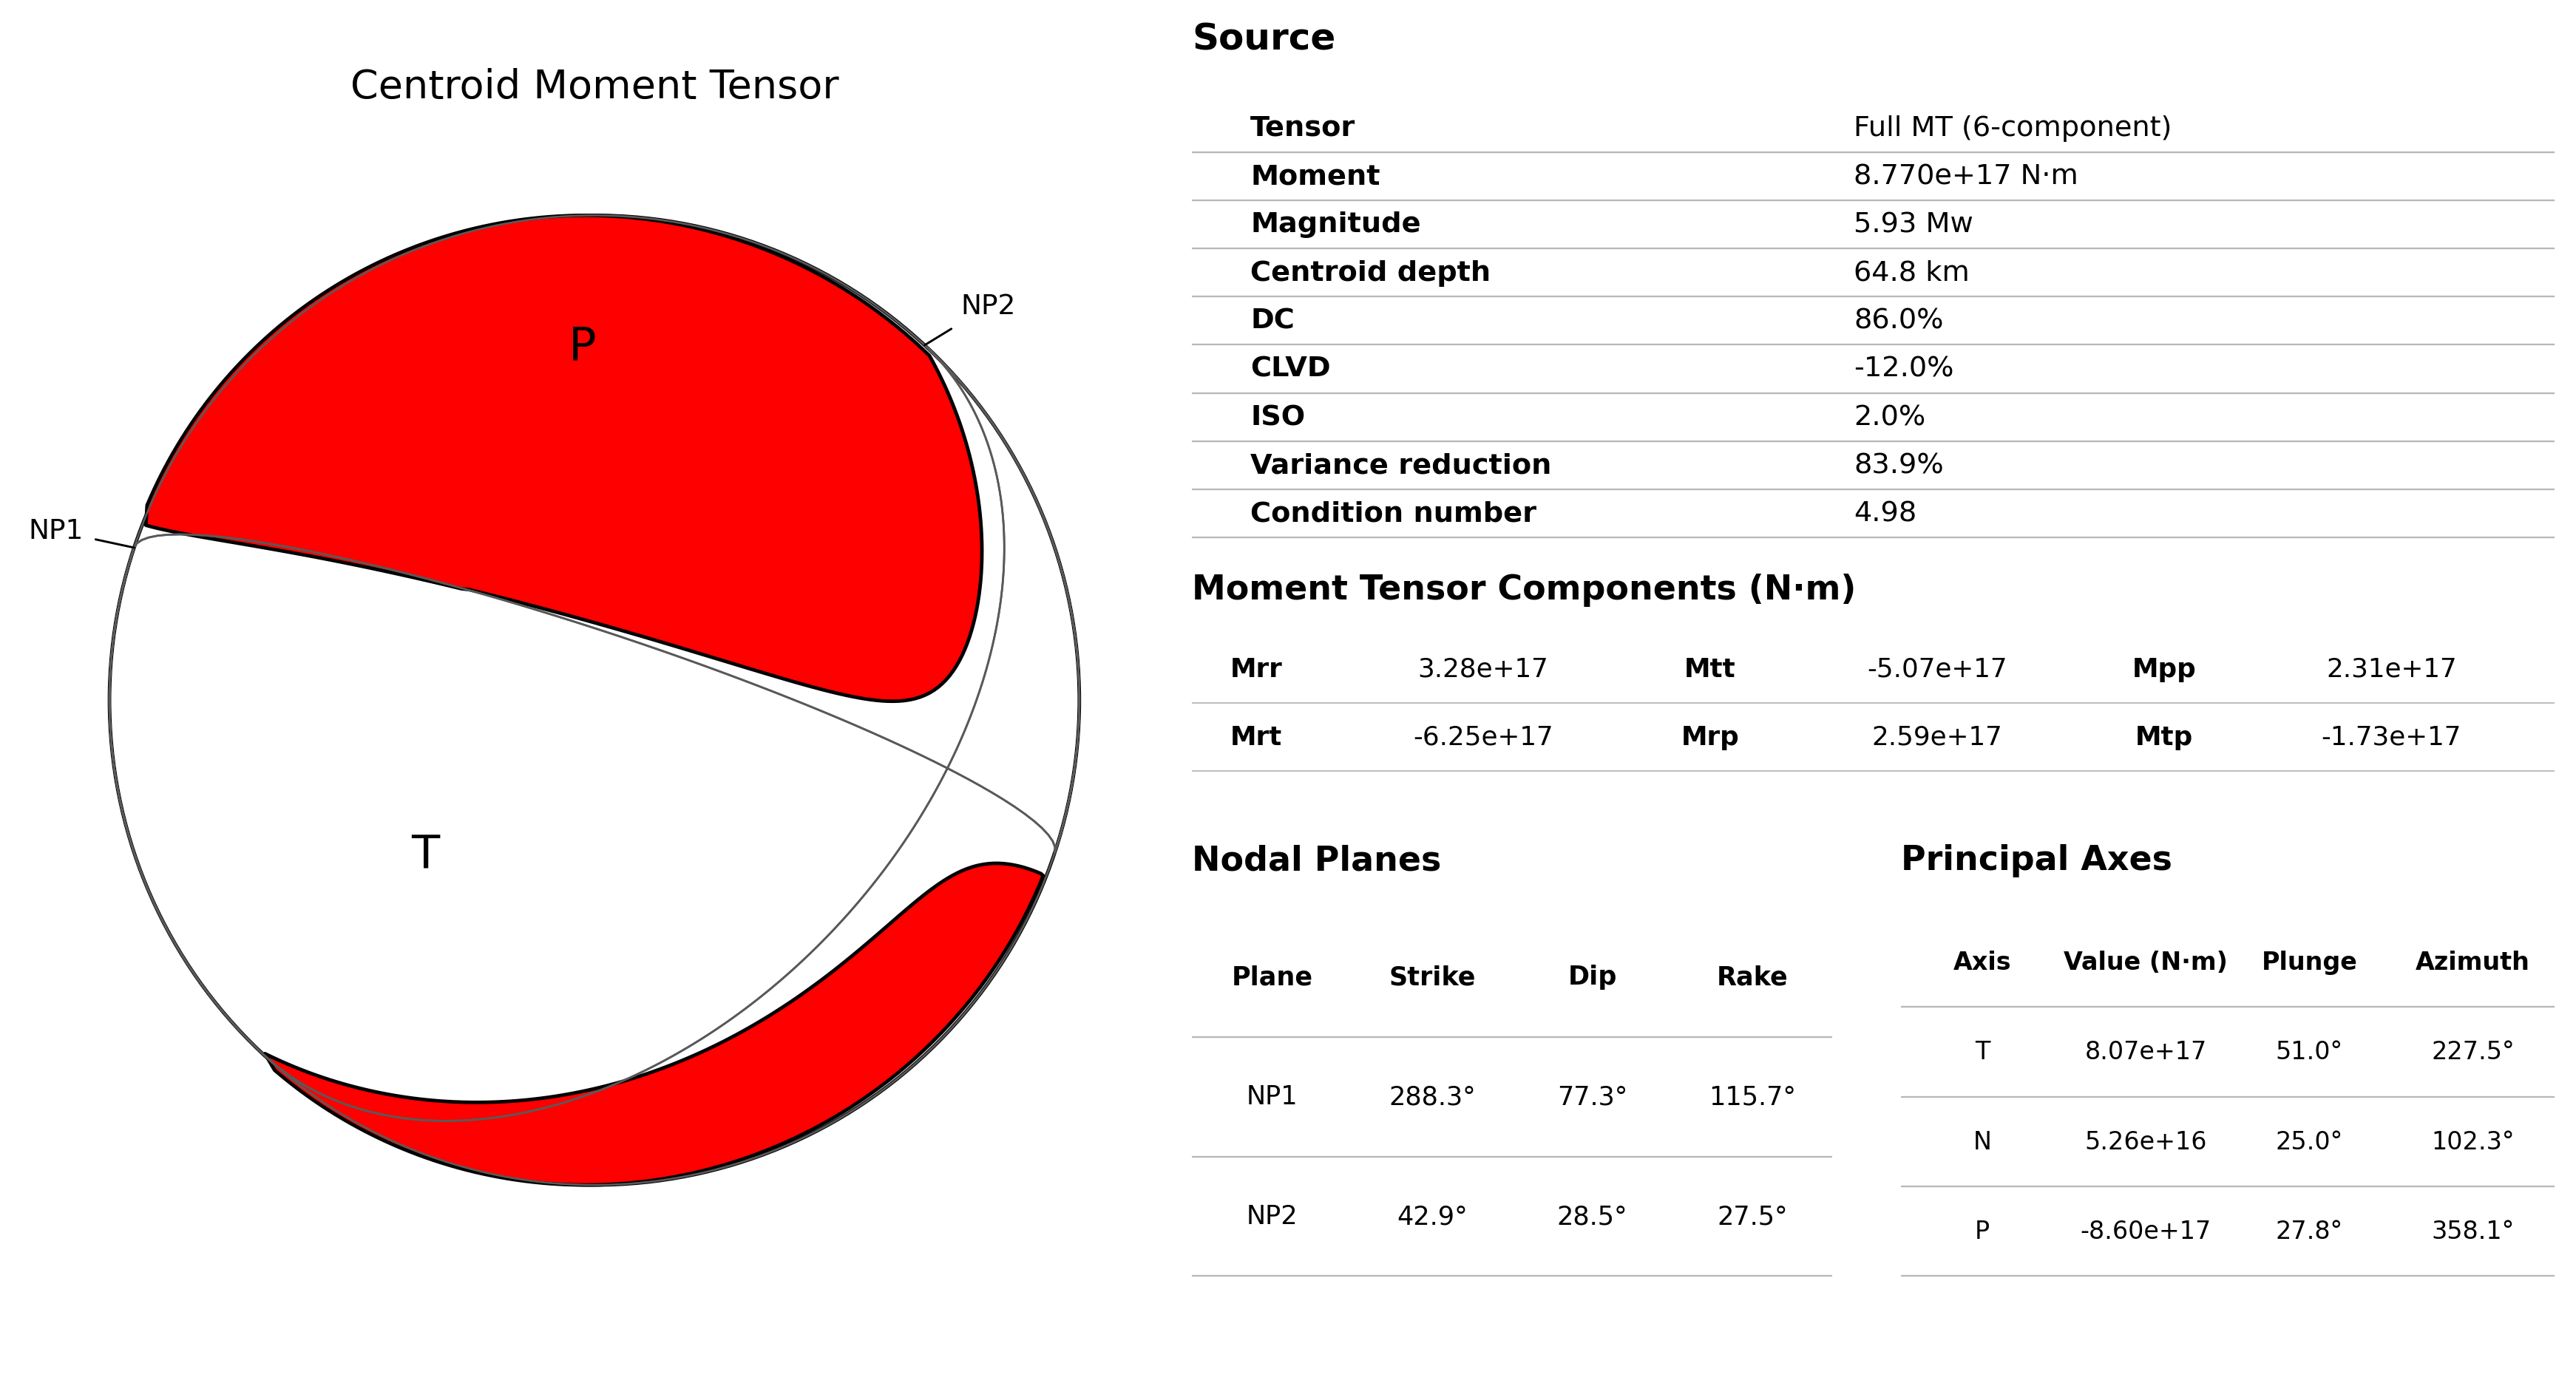

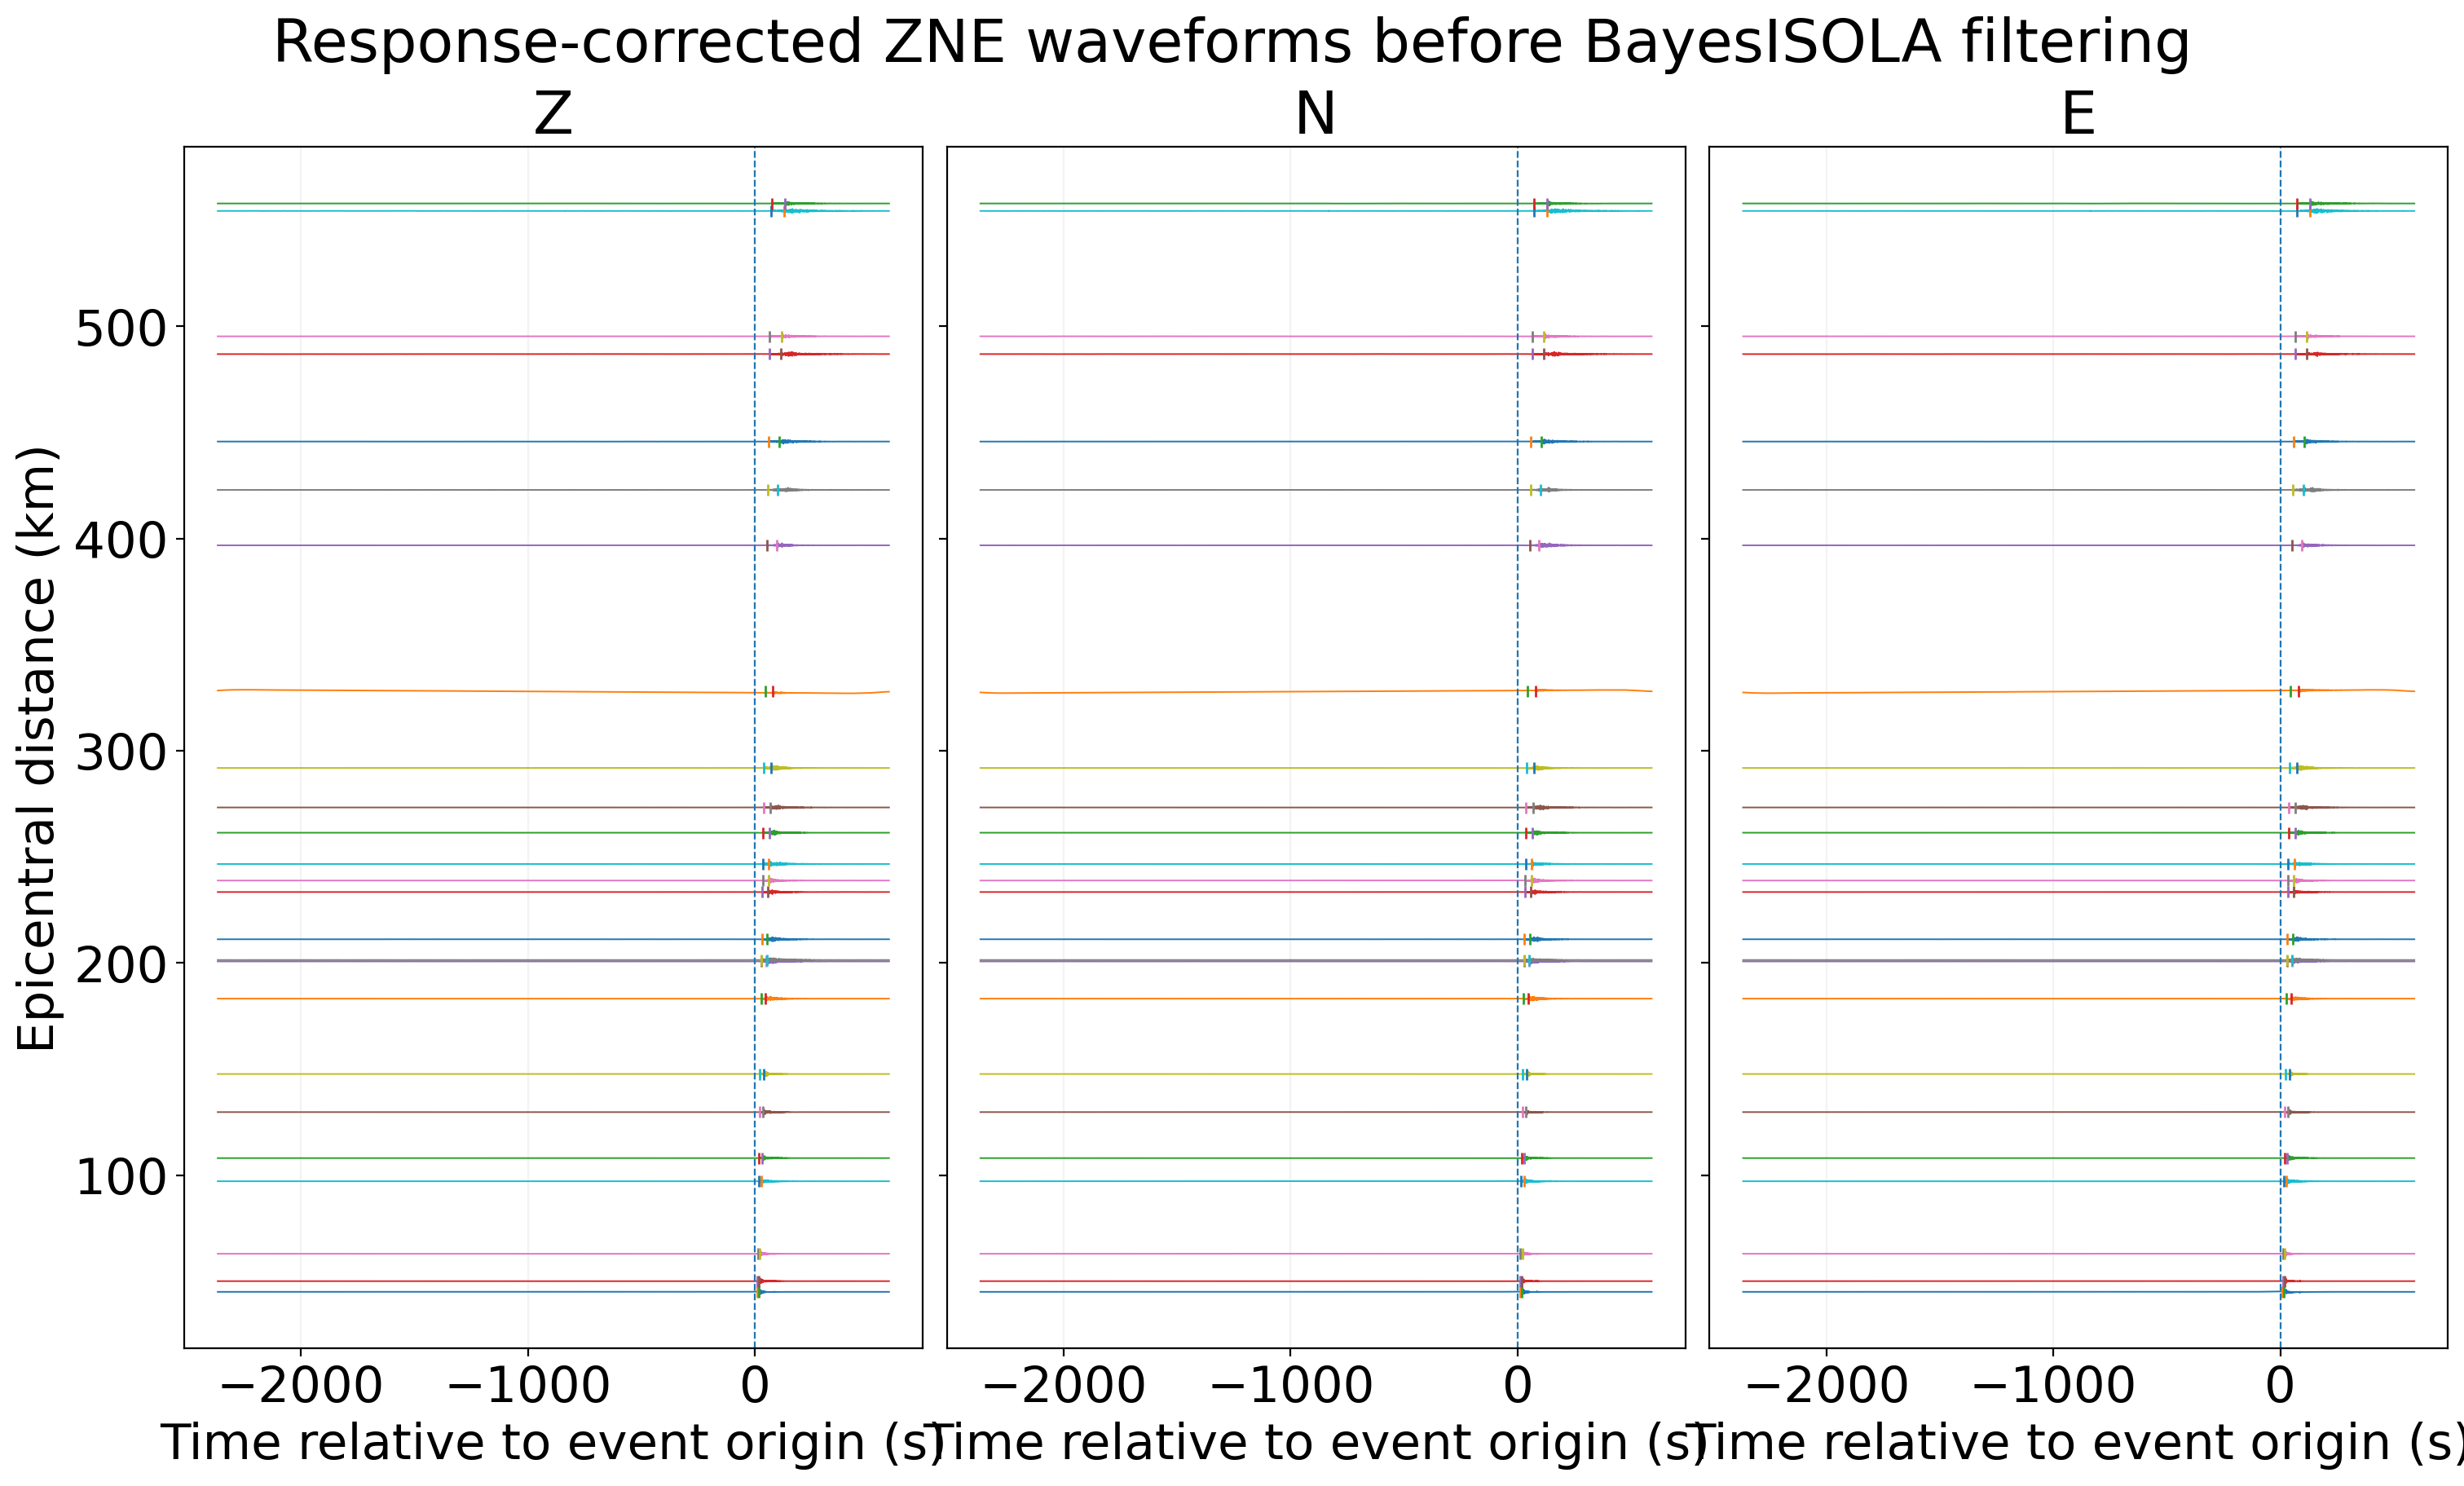

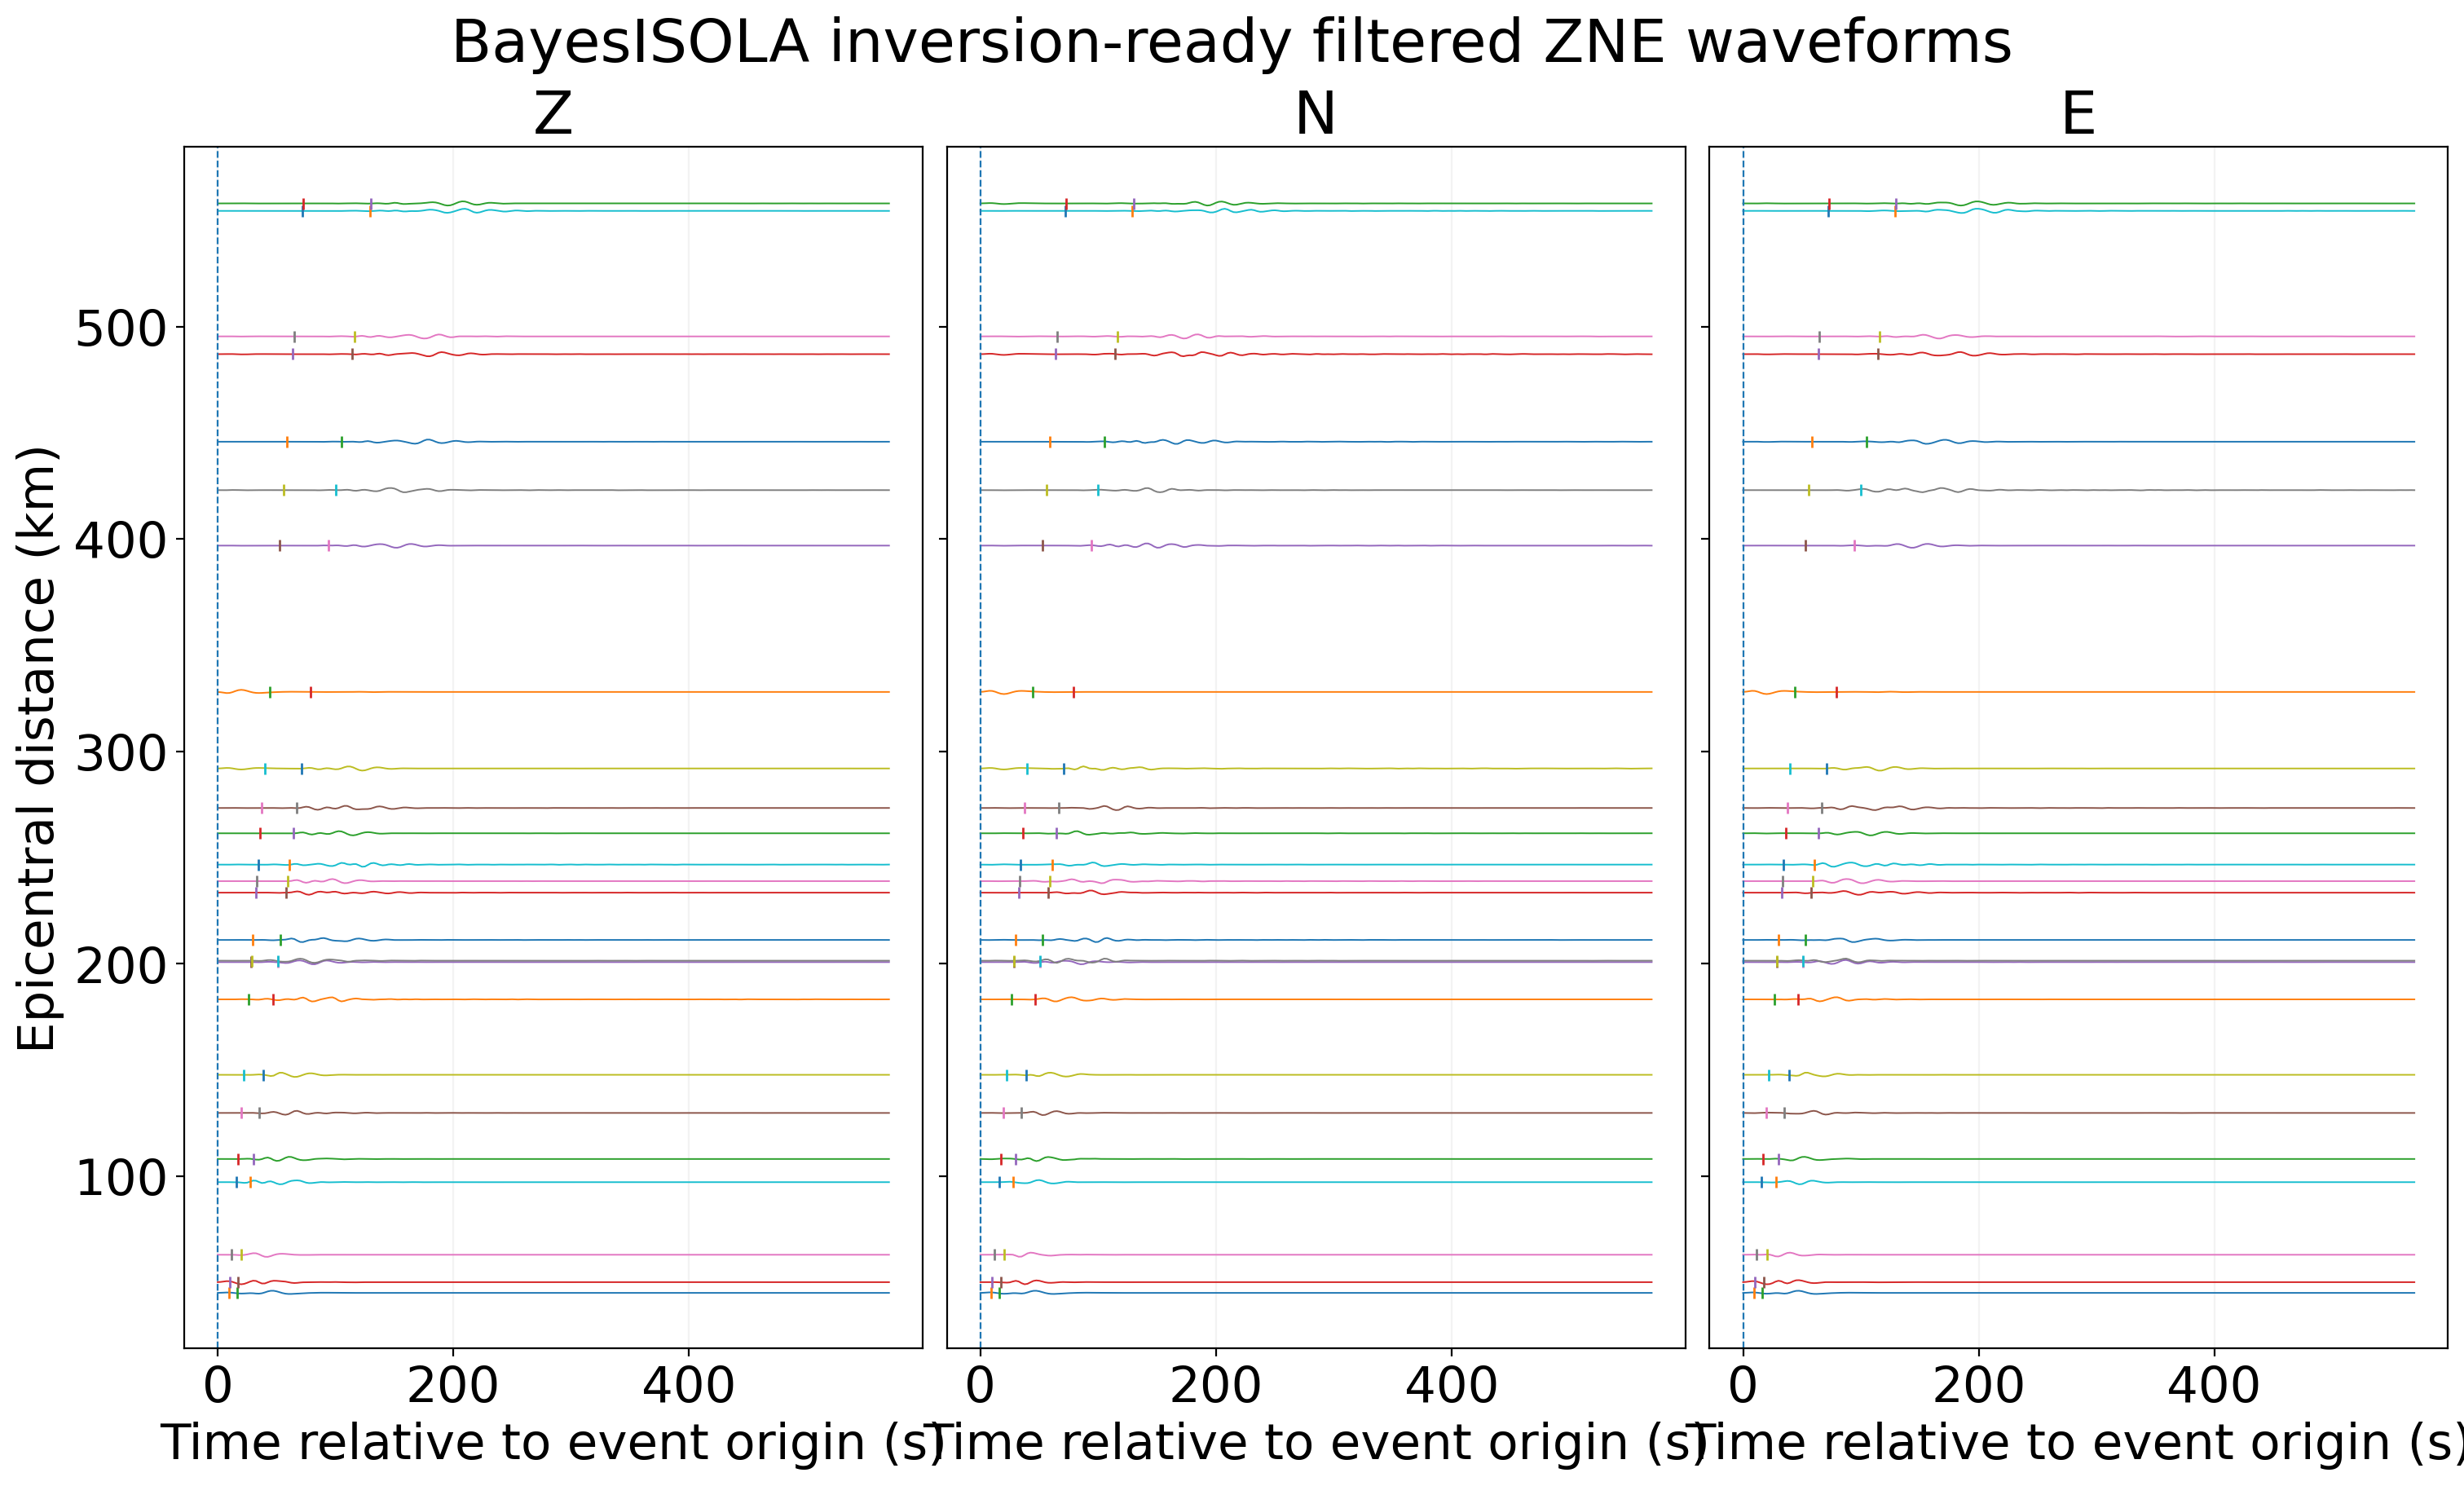

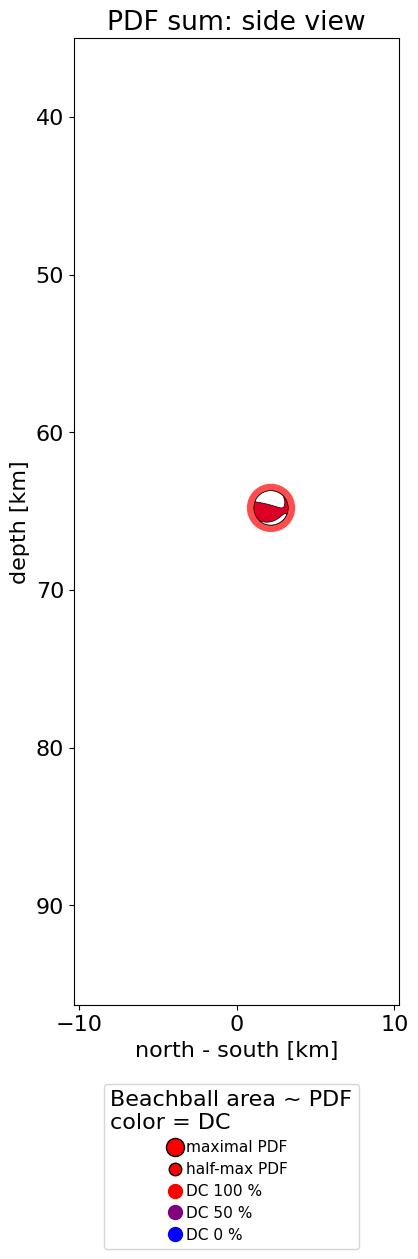

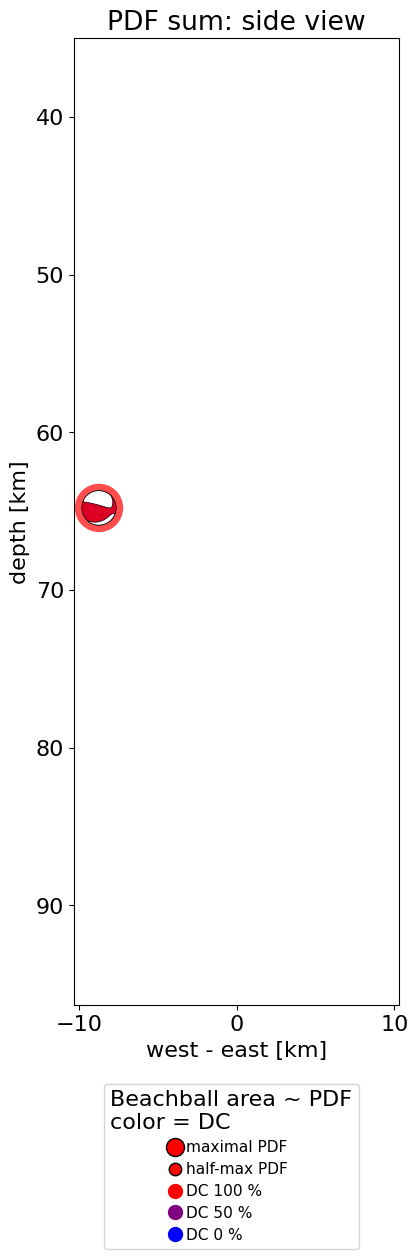

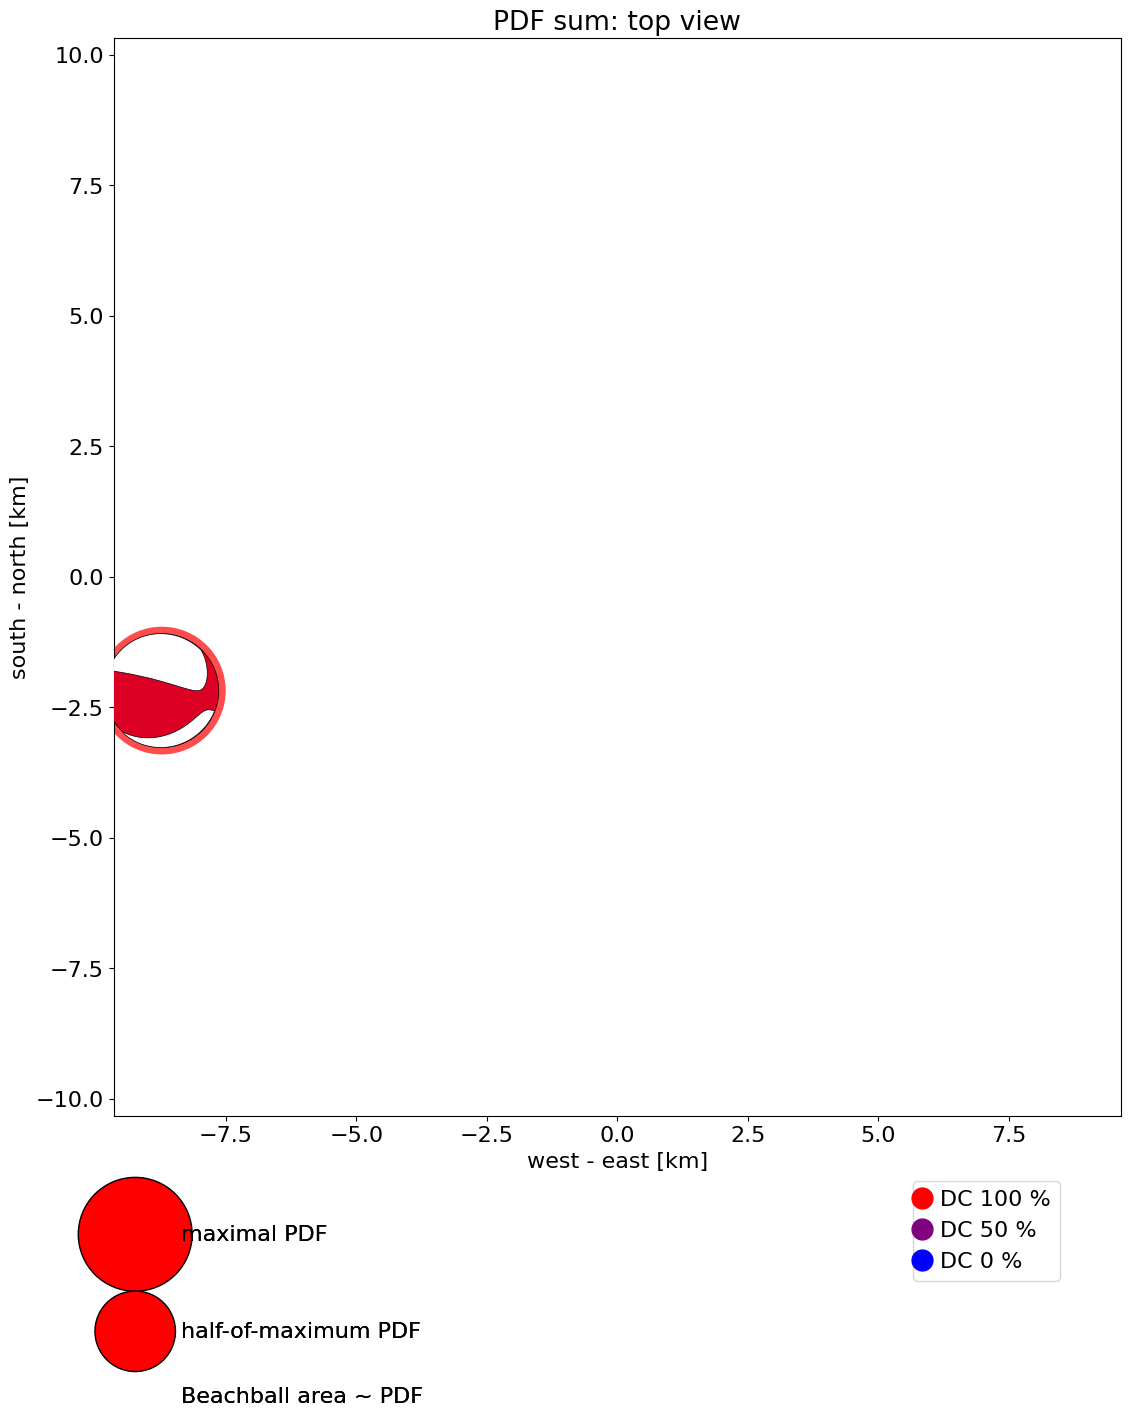

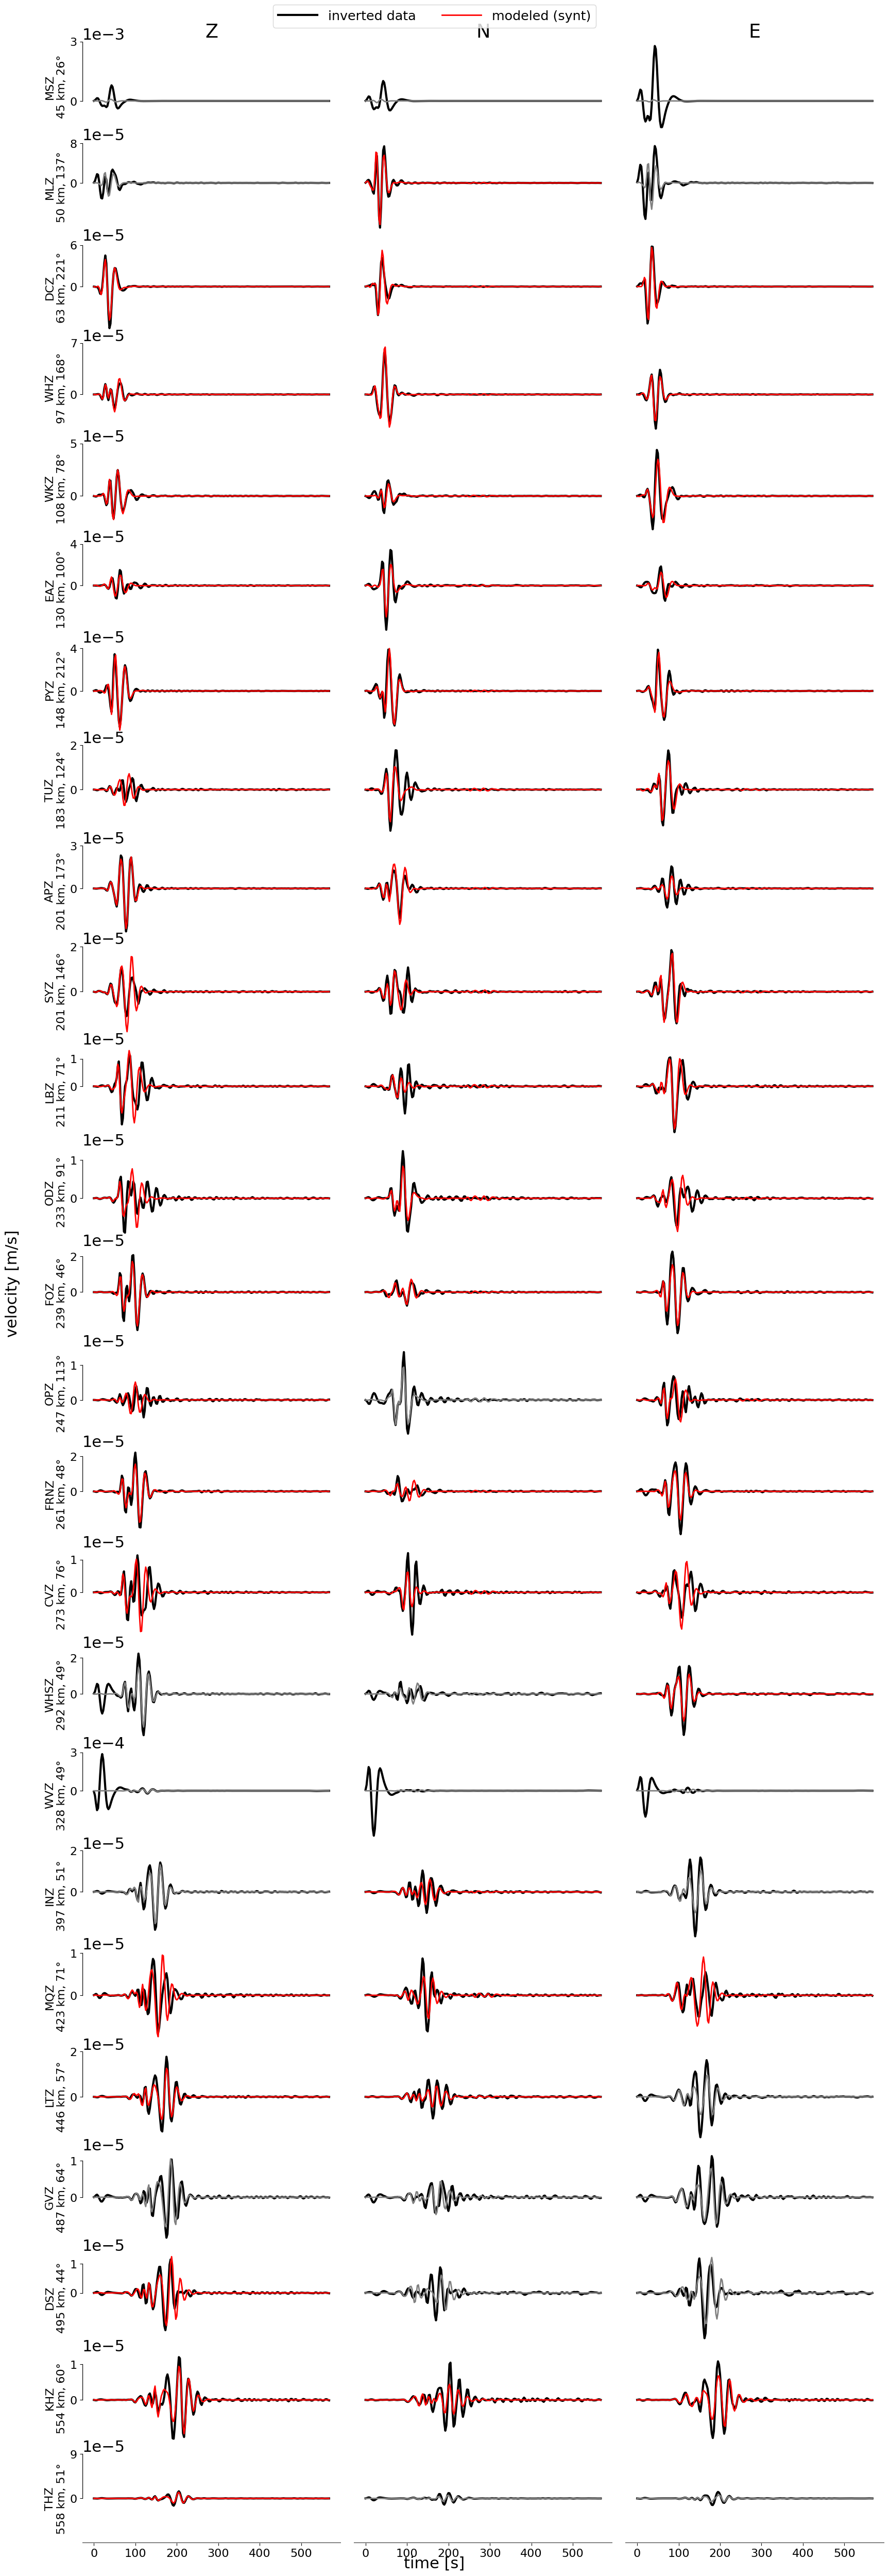

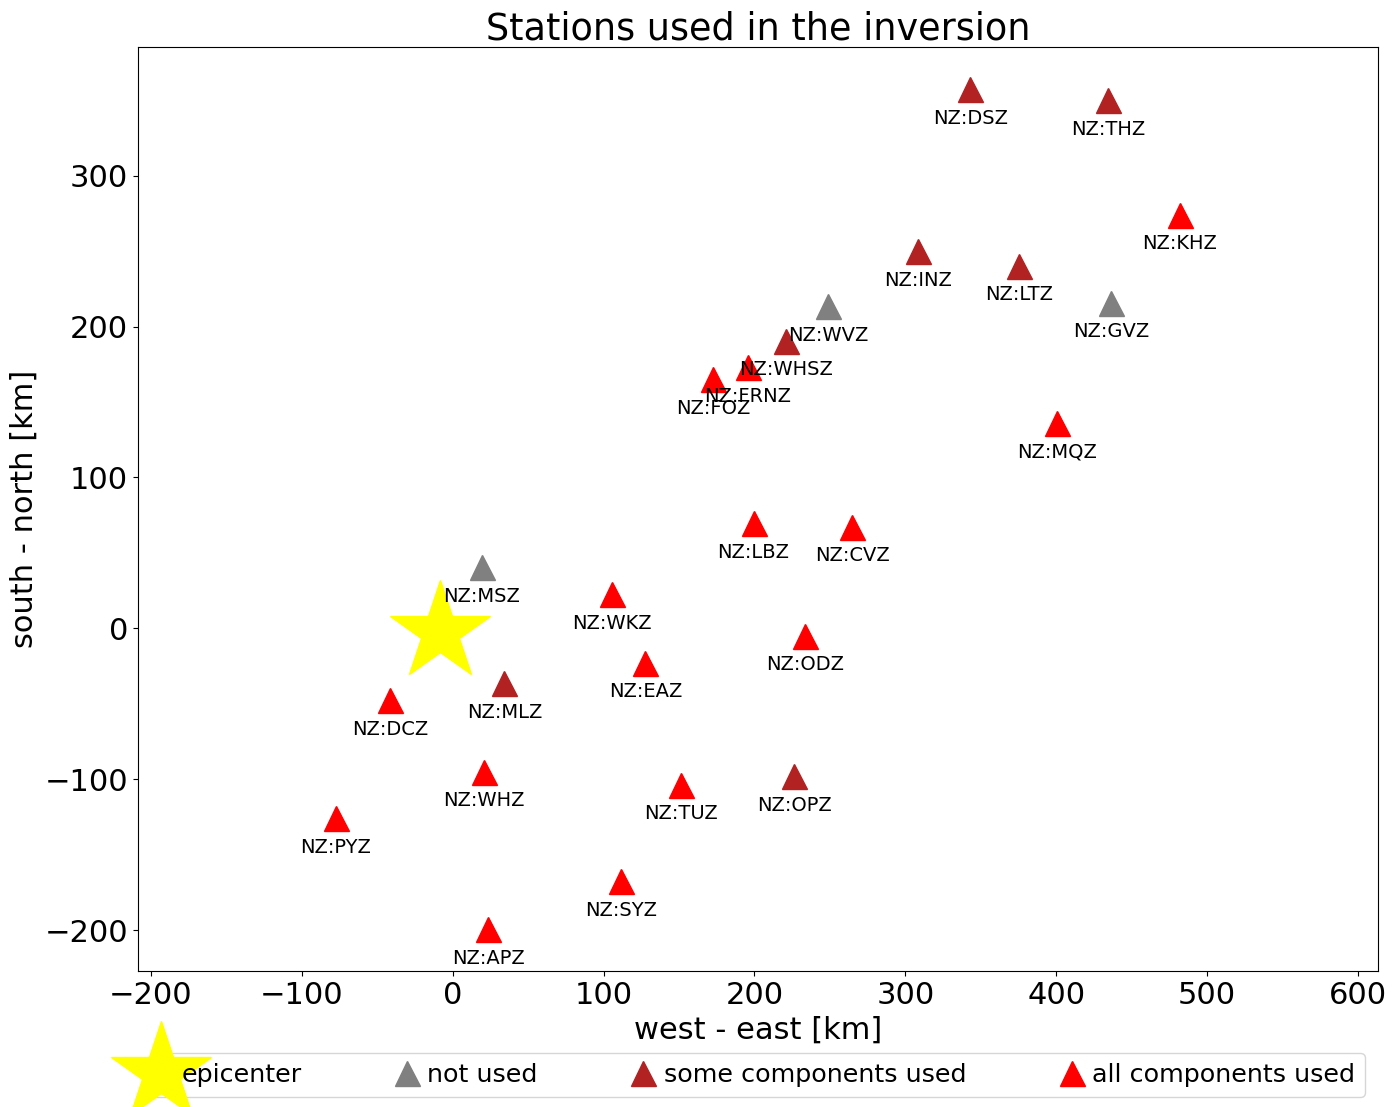

,origin_time,origin_lat,origin_lon,origin_depth_km,centroid_time,centroid_time_shift_s,centroid_lat,centroid_lon,centroid_depth_km,offset_north_m,offset_east_m,on_grid_edge,variance_reduction,condition_number
0,2026-07-16 09:14:54.328610,-45.038818,167.681931,37.517544,2026-07-16 09:14:57.728610,3.4,-45.058399,167.57112,64.793159,-2182.049227,-8728.19691,True,0.839123,4.982114


,variance_reduction,condition_number,Mrr,Mtt,Mpp,Mrt,Mrp,Mtp,M0_Nm,Mw,DC_percent,CLVD_percent,ISO_percent,NP1_strike_deg,NP1_dip_deg,NP1_rake_deg,NP2_strike_deg,NP2_dip_deg,NP2_rake_deg
0,0.839123,4.982114,3.275348e+17,-5.070309e+17,2.314484e+17,-6.252365e+17,2.592673e+17,-1.728611e+17,8.769781e+17,5.928659,86.020527,-12.004802,1.974671,288.336432,77.287367,115.688804,42.91969,28.469535,27.493184


,network,station,location,channelcode,component,distance_km,azimuth_deg,fmin_hz,fmax_hz,used,weight,variance_reduction
0,NZ,MSZ,10,HH,Z,44.978368,25.529913,0.02,0.05,False,1.0,NaN
1,NZ,MSZ,10,HH,N,44.978368,25.529913,0.02,0.05,False,1.0,NaN
2,NZ,MSZ,10,HH,E,44.978368,25.529913,0.02,0.05,False,1.0,NaN
3,NZ,MLZ,10,HH,Z,50.025741,136.878982,0.02,0.05,False,1.0,NaN
4,NZ,MLZ,10,HH,N,50.025741,136.878982,0.02,0.05,True,1.0,0.944110
...,...,...,...,...,...,...,...,...,...,...,...,...
70,NZ,KHZ,10,HH,N,554.427154,60.354289,0.02,0.05,True,1.0,0.645762
71,NZ,KHZ,10,HH,E,554.427154,60.354289,0.02,0.05,True,1.0,0.833169
72,NZ,THZ,10,HH,Z,557.945063,51.115282,0.02,0.05,True,1.0,0.854667
73,NZ,THZ,10,HH,N,557.945063,51.115282,0.02,0.05,False,1.0,NaN


None

,realized_radius_km,realized_step_x_km,realized_step_z_km,realized_depth_range_km,n_depth_levels_realized,n_steps_horizontal,centroid_edge_reasons
0,9.389911,2.182049,1.091025,"(18.97012535976565, 111.7072175245604)",86,4,"[horizontal index at max (i=-1, j=-4, n_steps=..."


Uncertainty not sampled.


In [11]:
run = run_auto_cmt(
    event_id, event_time, lon_event, lat_event, depth_km, mag_event,
    output_dir=output_path,
    velocity_model=nz_grid_ll,
    gf_source="axitra",
    # gf_options={"grid": "station"},
    gf_options={
        "grid": "path",
        "path_spacing_km": 2.0,
        "path_profile": "median",
    },
    # gf_options={"model": "prem_a_2s",
    #             "max_workers": 5},
    waveform_source="fdsn",
    client="GEONET",
    min_radius_km=min_radius_km,
    max_radius_km=None,
    ground_level=True,
    channels=("HH?", "BH?", "LH?"),
    channel_priority=("HH", "BH", "LH"),
    location_unc_km=0.0,
    time_unc_s=2.0,
    min_depth_km=5.0,
    min_depth_multiplier=0.5,
    max_depth_multiplier=3.0,
    step_x_km=2.0,
    step_z_km=1.0,
    max_grid_points=5000,
    add_rupture_length=True,
    rupture_velocity_m_s=1000.0,
    velocity_slowest_m_s=1000.0,
    freqmin=0.02,
    freqmax=0.05,
    threads=8,
    use_precalculated_Green="auto",
    covariance="noise",
    crosscovariance=True,
    # use_precalculated_Green=False,
    # covariance="none",
    # crosscovariance=False,
    n_uncertainty=None,
    plot=True,
    plot_preset="summary",
    show=True,
)

results = run["results"]

centroid = results["centroid"]
summary = results["summary"]
station_fit = results["station_fit"]
unc_df = results["uncertainty"]
unc_diagnostics = results["uncertainty_diagnostics"]
grid_edge = results["grid_edge_report"]

display(centroid)
display(summary)
display(station_fit)
display(unc_diagnostics)
display(grid_edge)

print(f"Uncertainty draws: {len(unc_df)}" if unc_df is not None else "Uncertainty not sampled.")

## 2.2 Auto CMT: Local model

### 2.2.1 Get stations/stationxmls

In [ ]:
event_df, stations_local, download_log, download_window = get_mseed_stationxml(
    event_id, event_time, lon_event, lat_event, depth_km,
    magnitude=mag_event,
    output_dir=output_path,
    client="GEONET",
    min_radius_km=min_radius_km,
    max_radius_km=None,
    ground_level=True,
    channels=("HH?", "BH?", "LH?"),
    channel_priority=("HH", "BH", "LH"),
    min_depth_km=5.0,
    min_depth_multiplier=0.5,
    max_depth_multiplier=3.0,
    time_unc_s=2.0,
    rupture_velocity_m_s=1000.0,
    velocity_slowest_m_s=1000.0,
    covariance="noise",
    plot=True,
    show=True,
)

### 2.2.2 Run auto CMT

In [ ]:
run_local = run_auto_cmt(
    event_id, event_time, lon_event, lat_event, depth_km, mag_event,
    output_dir=output_path,
    velocity_model=nz_grid_ll,

    waveform_source="local",
    station_df=stations_local,
    min_radius_km=min_radius_km,
    max_radius_km=max_radius_km,

    location_unc_km=0.0,
    time_unc_s=2.0,
    min_depth_km=5.0,
    max_depth_multiplier=3.0,
    step_x_km=2.0,
    step_z_km=1.0,
    max_grid_points=5000,
    add_rupture_length=True,
    rupture_velocity_m_s=1000.0,

    velocity_slowest_m_s=1000.0,
    freqmin=0.02,
    freqmax=0.05,
    threads=12,
    use_precalculated_Green="auto",

    covariance="noise",
    crosscovariance=False,
    n_uncertainty=1000,

    plot=True,
    plot_preset="summary",
    show=True,
)

results = run["results"]

centroid = results["centroid"]
summary = results["summary"]
station_fit = results["station_fit"]
unc_df = results["uncertainty"]
unc_diagnostics = results["uncertainty_diagnostics"]
grid_edge = results["grid_edge_report"]

display(centroid)
display(summary)
display(station_fit)
display(unc_diagnostics)
display(grid_edge)

print(f"Uncertainty draws: {len(unc_df)}" if unc_df is not None else "Uncertainty not sampled.")